# Labeling anomalious days


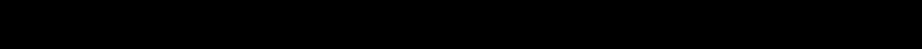
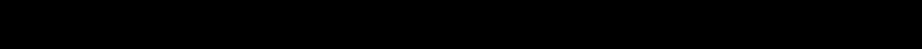
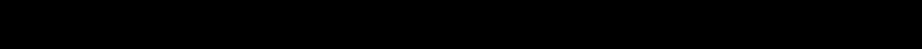

In [2]:
import os
import pandas as pd

In [3]:
daily = pd.read_parquet("../data/processed/chain/scam_daily_cleaned.parquet")

## Check threshold sensitivity

In [4]:
import os
import pandas as pd

key_features = [
    'normal_sent_cnt', 'normal_recv_cnt', 'normal_total_cnt',
    'eth_sent_sum', 'eth_recv_sum', 'eth_net_flow',
    'uniq_peers_cnt', 'sessions_cnt',
    'active_span_min', 'burst_max_tx_5m'
]

# Exclude zero-activity days
zero_activity_mask = (daily[key_features].sum(axis=1) == 0)
excluded_days = zero_activity_mask.sum()

daily_filtered = daily.loc[~zero_activity_mask].copy()

print(f"Excluded {excluded_days} zero-activity days")
print(f"Remaining active days: {len(daily_filtered)}")

# -----------------------------
# STEP 2: Compute per-address Z-scores
# -----------------------------
z_df = daily_filtered[key_features].copy()

for feature in key_features:
    mean = daily_filtered.groupby("address")[feature].transform("mean")
    std = (
        daily_filtered.groupby("address")[feature]
        .transform("std")
        .replace(0, 1e-6)
    )

    z_df[feature] = (daily_filtered[feature] - mean) / std

# Combined anomaly score
daily_filtered["combined_z_score"] = z_df.abs().max(axis=1)

# Threshold Sensitivity Analysis
thresholds = [1.5, 2.0, 2.5, 3.0]

threshold_results = []

for t in thresholds:
    temp_labels = (daily_filtered["combined_z_score"] > t).astype(int)

    summary = daily_filtered.assign(is_anomalous=temp_labels) \
        .groupby("address")["is_anomalous"] \
        .sum() \
        .reset_index(name="anomaly_days")

    threshold_results.append({
        "threshold": t,
        "total_days": len(daily_filtered),
        "anomalous_days": temp_labels.sum(),
        "anomaly_day_ratio": temp_labels.mean(),
        "addresses_with_anomalies": (summary["anomaly_days"] > 0).sum()
    })

threshold_df = pd.DataFrame(threshold_results)

print(threshold_df)

Excluded 2743336 zero-activity days
Remaining active days: 162699
   threshold  total_days  anomalous_days  anomaly_day_ratio  \
0        1.5      162699           51111           0.314145   
1        2.0      162699           33295           0.204642   
2        2.5      162699           21599           0.132754   
3        3.0      162699           14422           0.088642   

   addresses_with_anomalies  
0                      3840  
1                      3347  
2                      2603  
3                      2211  


## Label days

* exclude 0 activity days
* compute per address baseline
* Combined anomaly score
* label anomalies using zscore threshold - 2.0
* drop addresses with 0 anomalies


In [6]:
import os
import pandas as pd

key_features = [
    'normal_sent_cnt', 'normal_recv_cnt', 'normal_total_cnt',
    'eth_sent_sum', 'eth_recv_sum', 'eth_net_flow',
    'uniq_peers_cnt', 'sessions_cnt',
    'active_span_min', 'burst_max_tx_5m'
]

threshold = 2.0
output_folder = "../data/all_addresses"
os.makedirs(output_folder, exist_ok=True)

# Exclude zero-activity days
zero_activity_mask = (daily[key_features].sum(axis=1) == 0)
excluded_days = zero_activity_mask.sum()

daily_filtered = daily.loc[~zero_activity_mask].copy()

print(f"Excluded {excluded_days} zero-activity days")
print(f"Remaining active days: {len(daily_filtered)}")

# Compute per-address Z-scores
z_df = daily_filtered[key_features].copy()

for feature in key_features:
    mean = daily_filtered.groupby("address")[feature].transform("mean")
    std = (daily_filtered.groupby("address")[feature].transform("std").replace(0, 1e-6))

    z_df[feature] = (daily_filtered[feature] - mean) / std

# Combined anomaly score
daily_filtered["combined_z_score"] = z_df.abs().max(axis=1)

# Label anomalies
daily_filtered["is_anomalous"] = (daily_filtered["combined_z_score"] > threshold).astype(int)

# Create per-address summary
summary_df = daily_filtered.groupby("address").agg(
    total_active_days=("day", "count"),
    anomaly_days=("is_anomalous", "sum")).reset_index()


# Drop addresses with 0 anomalous days
valid_addresses = summary_df.loc[summary_df["anomaly_days"] > 0, "address"]

print(f"Addresses with ≥1 anomaly: {len(valid_addresses)}")

daily_final = daily_filtered[daily_filtered["address"].isin(valid_addresses)].copy()
summary_final = summary_df[summary_df["address"].isin(valid_addresses)].copy()

# Save FINAL datasets
anomalies_file = os.path.join(output_folder,"all_addresses_anomalies_final.parquet")
summary_file = os.path.join(output_folder,"all_addresses_summary_final.csv")

daily_final.to_parquet(anomalies_file, index=False)
summary_final.to_csv(summary_file, index=False)

print(f"Saved FINAL anomalies file: {anomalies_file}")
print(f"Saved FINAL summary file: {summary_file}")


Excluded 2743336 zero-activity days
Remaining active days: 162699
Addresses with ≥1 anomaly: 3347
Saved FINAL anomalies file: ../data/all_addresses\all_addresses_anomalies_final.parquet
Saved FINAL summary file: ../data/all_addresses\all_addresses_summary_final.csv
